In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
base_path="/kaggle/input/datasets/abdallahalidev/plantvillage-dataset"
print(os.listdir(base_path))

['segmented', 'grayscale', 'plantvillage dataset', 'color']


In [2]:
data_dir="/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

classes=os.listdir(data_dir)
print("No of classes: ",len(classes))
print(classes[:10])

No of classes:  38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [3]:
class_counts={}

for class_name in classes:
    class_path=os.path.join(data_dir,class_name)
    class_counts[class_name]=len(os.listdir(class_path))

total_images=sum(class_counts.values())

print(total_images)
print("Average images per class:",total_images/len(classes))

54305
Average images per class: 1429.078947368421


In [4]:
df=pd.DataFrame.from_dict(class_counts,orient='index',columns=['count'])
df=df.sort_values(by='count',ascending=False)

df.head()

,count
Orange___Haunglongbing_(Citrus_greening),5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
Soybean___healthy,5090
Peach___Bacterial_spot,2297
Tomato___Bacterial_spot,2127


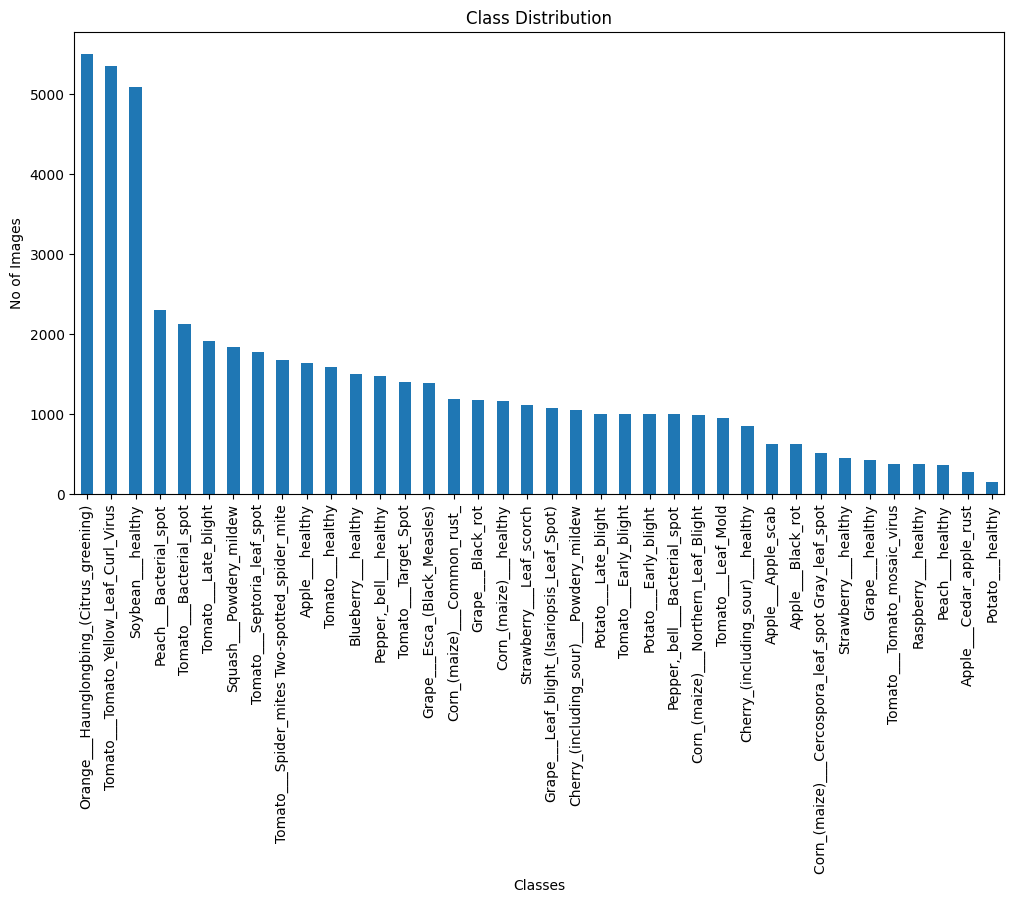

In [5]:
plt.figure(figsize=(12,6))
df['count'].plot(kind='bar')
plt.title("Class Distribution")
plt.ylabel("No of Images")
plt.xlabel("Classes")
plt.show()

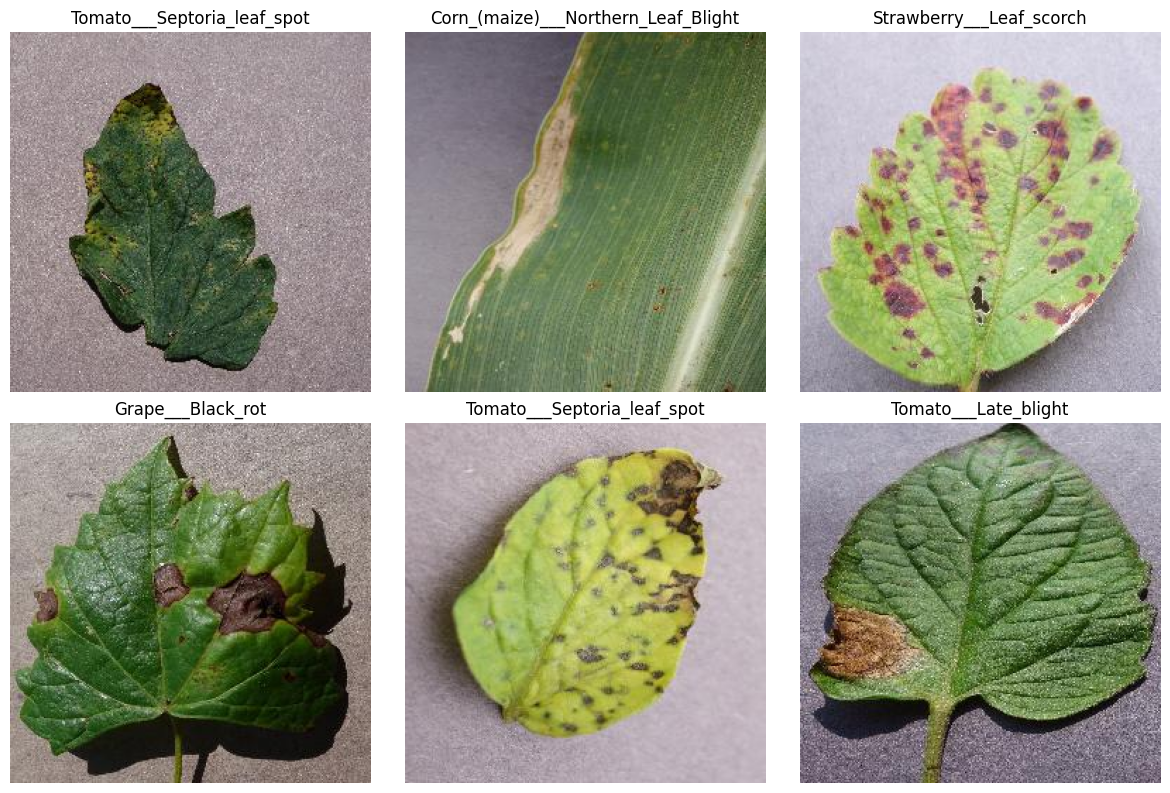

In [6]:
import random 
from PIL import Image

plt.figure(figsize=(12,8))

for i in range(6):
    random_class=random.choice(classes)
    class_path= os.path.join(data_dir, random_class)
    random_image=random.choice(os.listdir(class_path))
    img_path=os.path.join(class_path, random_image)

    img=Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(random_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import numpy as np

image_sizes = []

for class_name in classes[:5]:  # check first 5 classes for speed
    class_path = os.path.join(data_dir, class_name)
    images = os.listdir(class_path)[:20]  # check first 20 images
    
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        image_sizes.append(img.size)  # (width, height)

unique_sizes = set(image_sizes)
print("Unique Image Sizes Found:", unique_sizes)

Unique Image Sizes Found: {(256, 256)}


In [8]:
sample_class = classes[0]
sample_image = os.listdir(os.path.join(data_dir, sample_class))[0]
img_path = os.path.join(data_dir, sample_class, sample_image)

img = Image.open(img_path)
print("Image mode:", img.mode)

Image mode: RGB


In [9]:
corrupted_images = []

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    for img_name in os.listdir(class_path)[:50]:  # partial check
        img_path = os.path.join(class_path, img_name)
        try:
            Image.open(img_path)
        except:
            corrupted_images.append(img_path)

print("Corrupted Images Found:", len(corrupted_images))

Corrupted Images Found: 0


In [10]:
healthy_count = 0
disease_count = 0

for class_name in classes:
    if "healthy" in class_name.lower():
        healthy_count += class_counts[class_name]
    else:
        disease_count += class_counts[class_name]

print("Healthy Images:", healthy_count)
print("Diseased Images:", disease_count)

Healthy Images: 15084
Diseased Images: 39221


# EDA Summary

Total images: 54,305

Classes: 38

Image size: 256×256 RGB

Corrupted images: 0

Healthy images: 15,084

Diseased images: 39,221

Slight class imbalance observed

Controlled background → augmentation required